In [255]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv


# AI-Powered Demand Forecasting and Inventory Optimization

## Business Problem

Demand forecasting is critical for businesses to maintain optimal inventory levels, reduce stockouts, and minimize holding costs.

This project develops a machine learning solution that predicts future product demand using inventory, pricing, promotion, seasonality, and external factors.

## Objectives

- Analyze factors affecting demand
- Forecast future demand accurately
- Identify key demand drivers
- Generate inventory recommendations

# 1. Importing required Libraries

In [256]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

## Dataset Overview

The dataset contains 76,000 observations and 16 features describing:

- Product Information
- Store Information
- Inventory Levels
- Pricing
- Promotions
- Weather Conditions
- Seasonality
- Epidemic Impact

Target Variable:
- Demand

# 2. Loading the dataset

In [257]:
df = pd.read_csv("/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv")

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


# 3. Understanding The Dataset

In [258]:
print(df.shape)

df.info()

(76000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64

In [259]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


The dataset contains 76,000 records and 16 features describing sales, inventory, pricing, promotions, seasonality and demand.

# 4. Missing Value Check

In [260]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

The dataset contains no missing values. Therefore, no imputation or data cleaning for null values was required before model development.

# 5. Feature Engineering

In [261]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.dayofweek

In [262]:
df.drop('Date', axis=1, inplace=True)

# 6. Exploratory Data Analysis

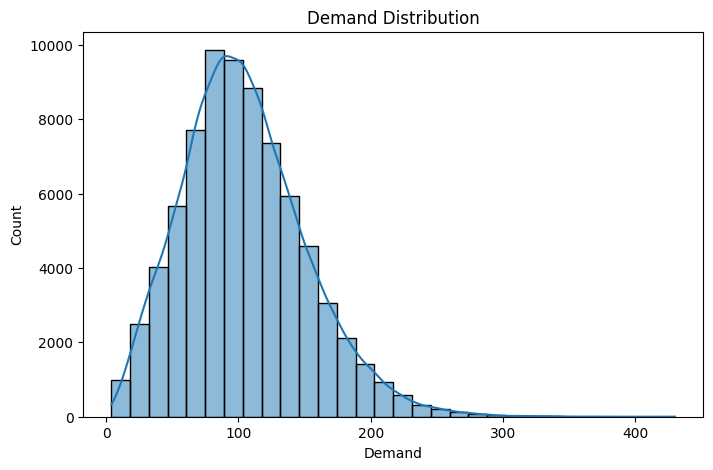

In [263]:
#DEMAND DISTRIBUTION

plt.figure(figsize=(8,5))
sns.histplot(df['Demand'], bins=30, kde=True)
plt.title('Demand Distribution')
plt.show()

### Insight

Demand is relatively well distributed, making the dataset suitable for regression modeling.

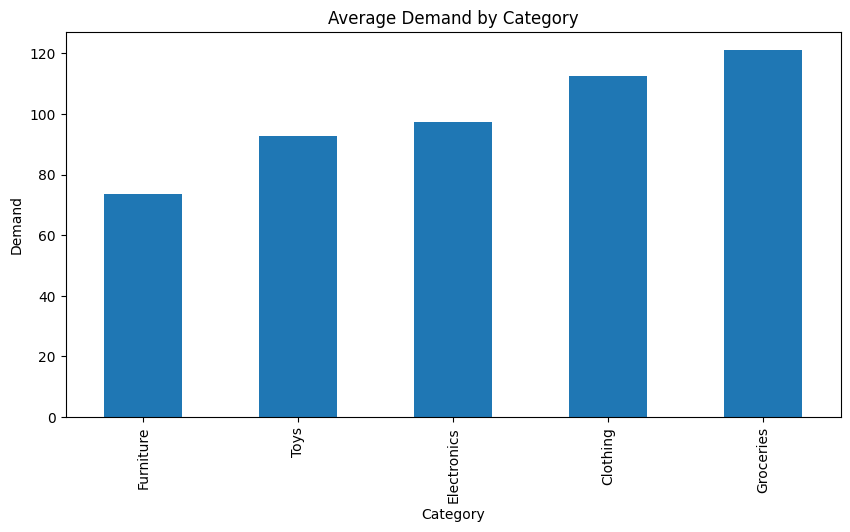

In [264]:
# CATEGORY WISE DEMAND

plt.figure(figsize=(10,5))

df.groupby('Category')['Demand'].mean().sort_values().plot(kind='bar')

plt.title("Average Demand by Category")
plt.ylabel("Demand")
plt.show()

Different product categories exhibit different demand patterns, indicating category-specific purchasing behavior.

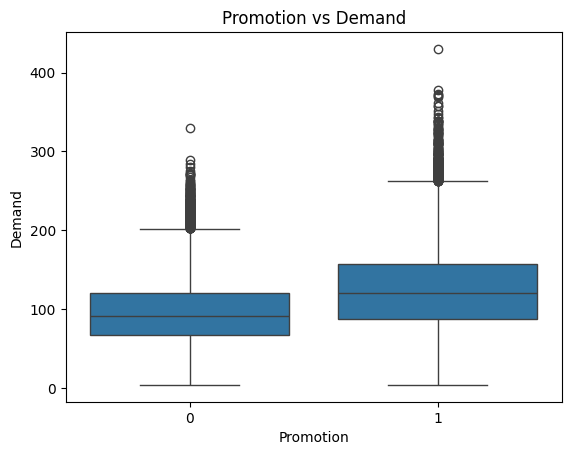

In [265]:
# PROMOTION ANALYSIS

sns.boxplot(
    x='Promotion',
    y='Demand',
    data=df
)

plt.title("Promotion vs Demand")
plt.show()

### Insight

Promotional campaigns consistently increase customer demand, confirming the importance of marketing activities.

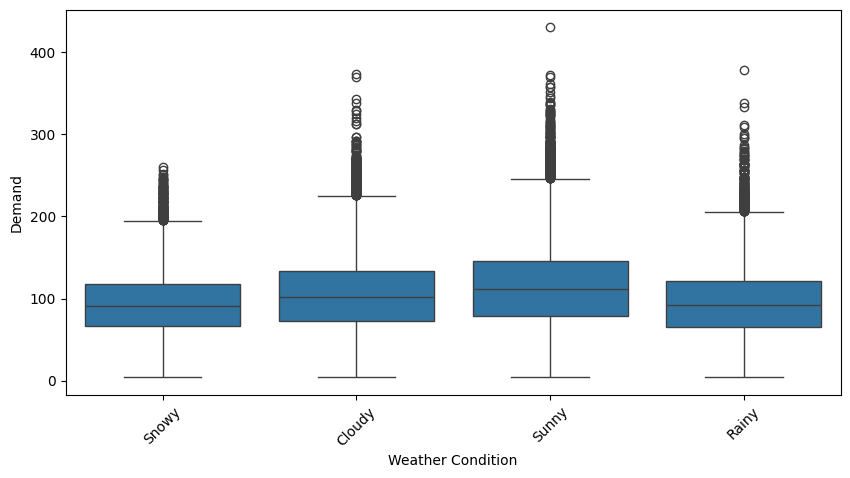

In [266]:
# WEATHER ANALYSIS

plt.figure(figsize=(10,5))

sns.boxplot(
    x='Weather Condition',
    y='Demand',
    data=df
)

plt.xticks(rotation=45)
plt.show()

### Insight

Weather conditions affect customer purchasing behavior and should be included in forecasting models.

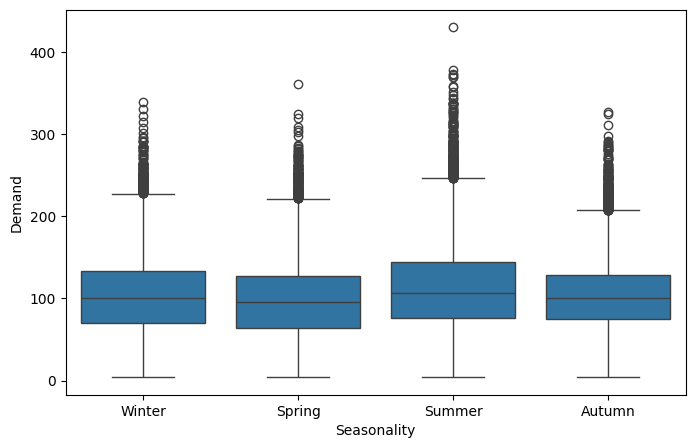

In [267]:
# SEASONALITY ANALYSIS

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Seasonality',
    y='Demand',
    data=df
)

plt.show()

### Insight

Seasonal variations significantly influence demand patterns, highlighting the need for time-aware forecasting.

# 7. Encoding Categorical Feature

In [268]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Weather Condition',
    'Seasonality'
]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

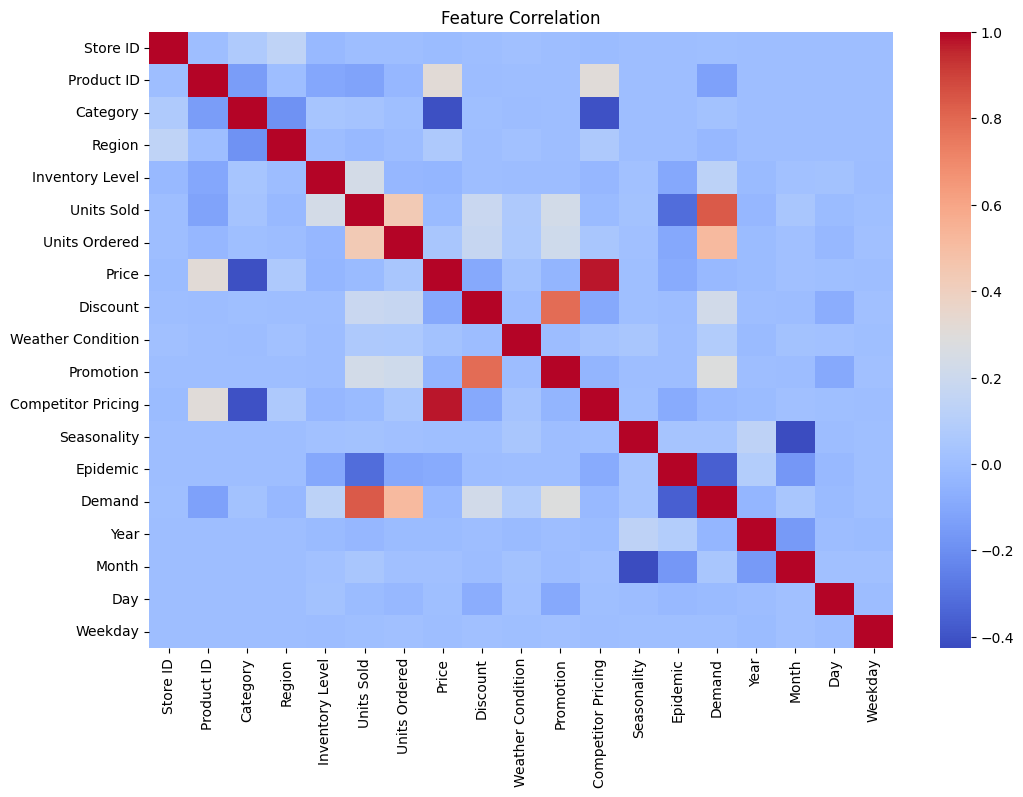

In [269]:
# CORRELATION HEATMAP


plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation")
plt.show()

In [270]:
# Dataset Preparation

X = df.drop('Demand', axis=1)
y = df['Demand']

# 8. Train - Test Split

In [271]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 9. Model Comparison

Two machine learning models were evaluated:

1. Random Forest Regressor
2. XGBoost Regressor

XGBoost achieved superior performance and was selected as the final forecasting model.

In [274]:
# 1. RANDOM FOREST


from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [275]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test,pred_rf)

rmse = np.sqrt(
    mean_squared_error(y_test,pred_rf)
)

r2 = r2_score(y_test,pred_rf)

print("MAE :",mae)
print("RMSE:",rmse)
print("R2 :",r2)

MAE : 12.731139144736842
RMSE: 16.95474637924553
R2 : 0.8698386352220656


In [276]:
# 2. XGBOOST REGRESSOR

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [277]:
mae = mean_absolute_error(y_test,pred_xgb)

rmse = np.sqrt(
    mean_squared_error(y_test,pred_xgb)
)

r2 = r2_score(y_test,pred_xgb)

print("MAE :",mae)
print("RMSE:",rmse)
print("R2 :",r2)

MAE : 9.97208309173584
RMSE: 13.282679151048086
R2 : 0.9201139807701111


In [278]:
comparison = pd.DataFrame({
    "Model":["Random Forest","XGBoost"],
    "MAE":[12.73,9.97],
    "RMSE":[16.95,13.28],
    "R2":[0.87,0.92]
})

comparison

,Model,MAE,RMSE,R2
0,Random Forest,12.73,16.95,0.87
1,XGBoost,9.97,13.28,0.92


## Actual VS Predicted Demand  

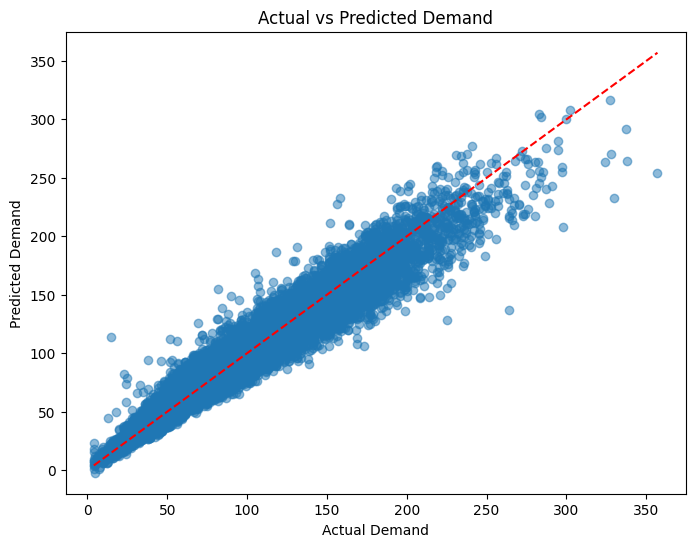

In [279]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_xgb, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.show()

### Insight

The predicted demand values closely follow the actual demand values, indicating that the XGBoost model captures the underlying demand patterns effectively. Most points lie near the ideal prediction line, demonstrating strong predictive performance with an R² score of 0.92.

# 10. Feature Importance Plot

In [280]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

              Feature  Importance
5          Units Sold    0.405189
13           Epidemic    0.172523
10          Promotion    0.092694
6       Units Ordered    0.092129
2            Category    0.077776
4     Inventory Level    0.029346
9   Weather Condition    0.018267
7               Price    0.016543
1          Product ID    0.013897
8            Discount    0.013701


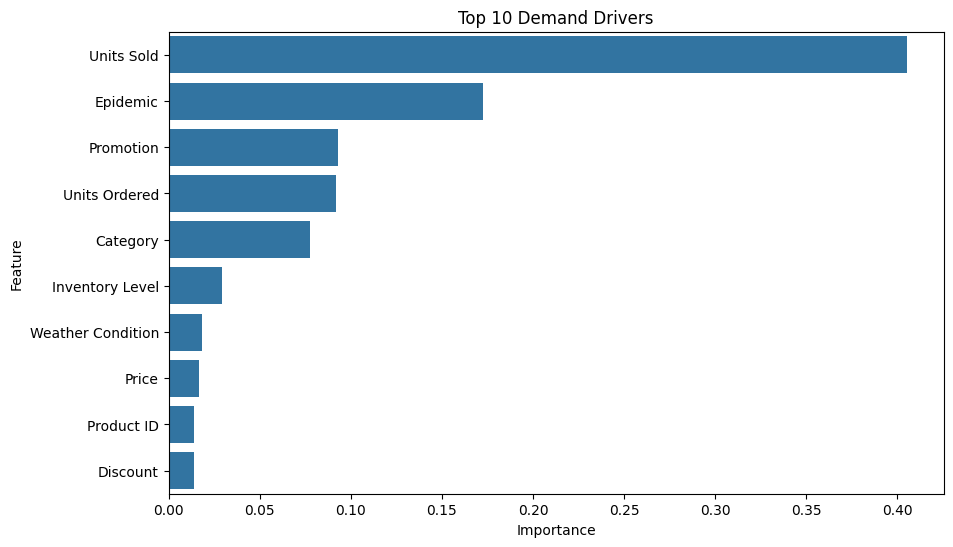

In [281]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Demand Drivers")
plt.show()

### Key Demand Drivers

The model identifies the most influential factors affecting demand.

These insights can support business decision-making related to inventory planning and pricing strategies.

# 11. Inventory Recommendation Section

In [282]:
recommendation = pd.DataFrame()

recommendation["Predicted Demand"] = pred_xgb[:20]

recommendation["Recommended Stock"] = (
    recommendation["Predicted Demand"] * 1.20
).round()

recommendation.head()

,Predicted Demand,Recommended Stock
0,102.429726,123.0
1,78.605545,94.0
2,41.165955,49.0
3,163.302719,196.0
4,96.303986,116.0


## Inventory Optimization Strategy

A safety stock buffer of 20% was added to predicted demand.

Recommended Stock = Forecasted Demand × 1.20

This approach helps businesses reduce stockouts while maintaining adequate inventory levels.

# 12. Business Recommendations

1. Increase inventory before high-demand seasons.
2. Use promotional campaigns strategically to boost sales.
3. Monitor competitor pricing regularly.
4. Adjust stock levels based on forecasted demand.
5. Incorporate weather and external events into planning processes.

# 13. Conclusion

This project successfully developed an AI-powered demand forecasting system using XGBoost.

Key Results:

- R² Score: 0.92
- MAE: 9.97
- RMSE: 13.28

The model accurately predicts future demand using inventory, pricing, promotion, seasonality, and market-related factors.

By leveraging these forecasts, businesses can optimize inventory management, reduce operational costs, and improve customer satisfaction.